# scratchkit — Unsupervised Learning, from scratch

Every clustering, dimensionality-reduction, and association-rule
algorithm in [`scratchkit`](https://pypi.org/project/scratchkit/)
(`import mlscratch`), implemented from scratch in pure NumPy.

`scikit-learn` appears in this notebook only as a source of real
datasets (Wine, Digits) — every algorithm below is `scratchkit`'s own.

**Algorithms covered:** KMeans, KMedoids, DBSCAN, Agglomerative
Clustering, PCA, t-SNE, FastICA, Gaussian Mixture Model, Apriori.


In [ ]:
!pip install -q scratchkit

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine, load_digits, make_moons

from mlscratch.unsupervised import (
    KMeans, KMedoids, DBSCAN, AgglomerativeClustering,
    PCA, TSNE, FastICA, GaussianMixtureModel, Apriori,
)
from mlscratch.preprocessing import StandardScaler

np.random.seed(0)
plt.rcParams["figure.figsize"] = (6, 4)
print("scratchkit imports OK")


scratchkit imports OK


## 1. Dataset — Wine (real data)

178 wines from three Italian cultivars, 13 chemical-analysis features
(alcohol, malic acid, ash, flavanoids, color intensity, ...). The class
labels exist for us to *check* clustering quality — the algorithms
themselves never see them.

In [3]:
wine = load_wine()
X, y_true = wine.data, wine.target
X = StandardScaler().fit_transform(X)
print(f"{X.shape[0]} wines, {X.shape[1]} features, {len(set(y_true))} true cultivars")


178 wines, 13 features, 3 true cultivars


## 2. PCA — dimensionality reduction

We'll use PCA's 2-D projection as a consistent backdrop to visualise
every clustering result below.

explained variance ratio: [0.362 0.192]
first 2 components explain 55.4% of the variance


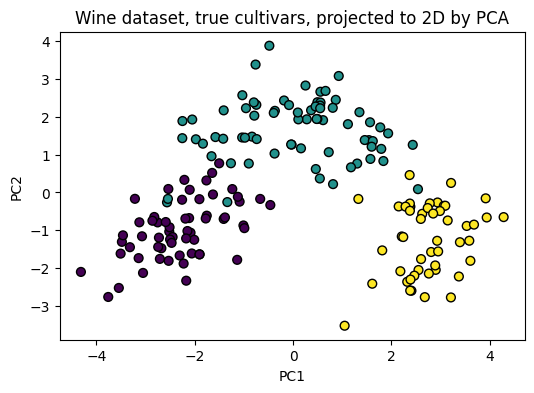

In [4]:
pca = PCA(n_components=2).fit(X)
X_2d = pca.transform(X)
print("explained variance ratio:", pca.explained_variance_ratio_.round(3))
print(f"first 2 components explain {pca.explained_variance_ratio_.sum():.1%} of the variance")

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_true, cmap="viridis", edgecolors="k", s=40)
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("Wine dataset, true cultivars, projected to 2D by PCA")
plt.show()


## 3. K-Means

Partitions data into $k$ clusters by alternately assigning points to
the nearest centroid and recomputing centroids — the classic Lloyd's
algorithm, with k-means++ initialisation.

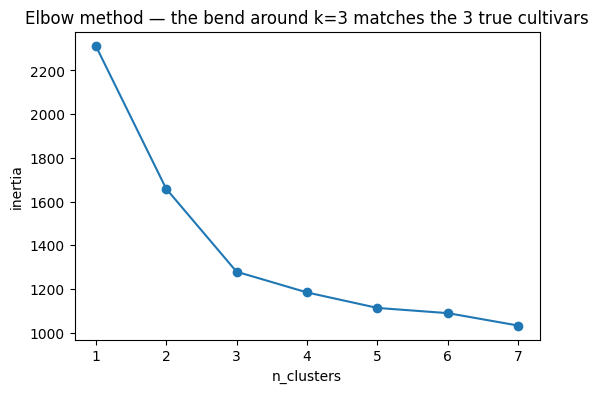

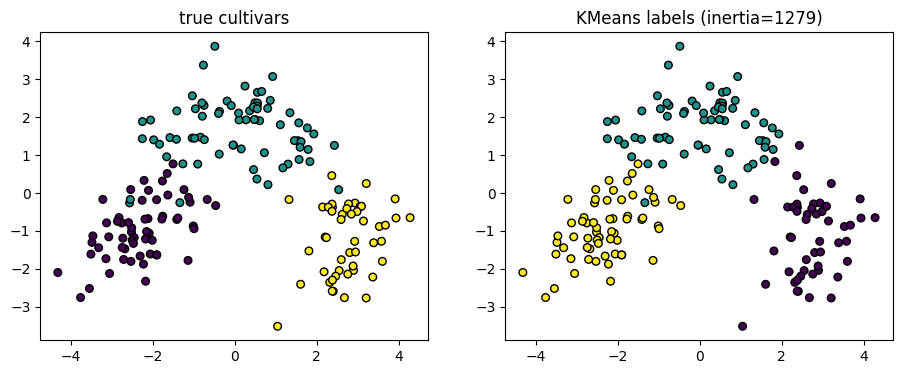

In [5]:
inertias = []
k_range = range(1, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=0).fit(X)
    inertias.append(km.inertia_)

plt.plot(list(k_range), inertias, "o-")
plt.xlabel("n_clusters"); plt.ylabel("inertia")
plt.title("Elbow method — the bend around k=3 matches the 3 true cultivars")
plt.show()

km = KMeans(n_clusters=3, random_state=0).fit(X)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=y_true, cmap="viridis", edgecolors="k", s=30)
axes[0].set_title("true cultivars")
axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=km.labels_, cmap="viridis", edgecolors="k", s=30)
axes[1].set_title(f"KMeans labels (inertia={km.inertia_:.0f})")
plt.show()


## 4. K-Medoids

Like K-Means, but every cluster "center" is an *actual data point*
(the medoid), not a synthetic mean — more robust to outliers since it
never averages.

In [6]:
kmedoids = KMedoids(n_clusters=3, random_state=0).fit(X)
agreement = max(
    np.mean(kmedoids.labels_ == perm)
    for perm in [y_true, (y_true + 1) % 3, (y_true + 2) % 3]
)
print(f"medoid indices (actual wine samples used as centers): {kmedoids.medoid_indices_}")
print(f"best label-permutation agreement with true cultivars: {agreement:.1%}")


medoid indices (actual wine samples used as centers): [ 35 106 148]
best label-permutation agreement with true cultivars: 91.0%


## 5. DBSCAN — density-based clustering, no `n_clusters` needed

DBSCAN doesn't need to be told how many clusters to find — it grows
clusters from dense regions and labels sparse points as noise. We
demonstrate it on two interleaving half-moons, a shape K-Means
fundamentally cannot separate (it only finds convex/spherical
clusters).

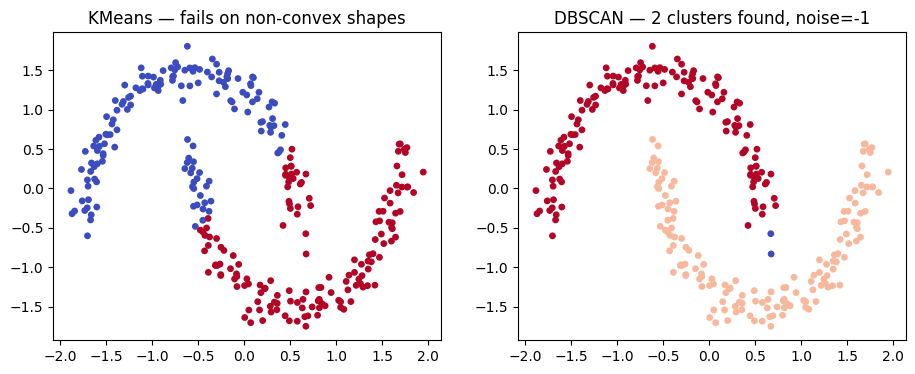

In [7]:
Xm, ym = make_moons(n_samples=300, noise=0.07, random_state=0)
Xm = StandardScaler().fit_transform(Xm)

km_moons = KMeans(n_clusters=2, random_state=0).fit(Xm)
db_moons = DBSCAN(eps=0.25, min_samples=5).fit(Xm)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(Xm[:, 0], Xm[:, 1], c=km_moons.labels_, cmap="coolwarm", s=15)
axes[0].set_title("KMeans — fails on non-convex shapes")
axes[1].scatter(Xm[:, 0], Xm[:, 1], c=db_moons.labels_, cmap="coolwarm", s=15)
axes[1].set_title(f"DBSCAN — {len(set(db_moons.labels_) - {-1})} clusters found, noise=-1")
plt.show()


## 6. Agglomerative (Hierarchical) Clustering

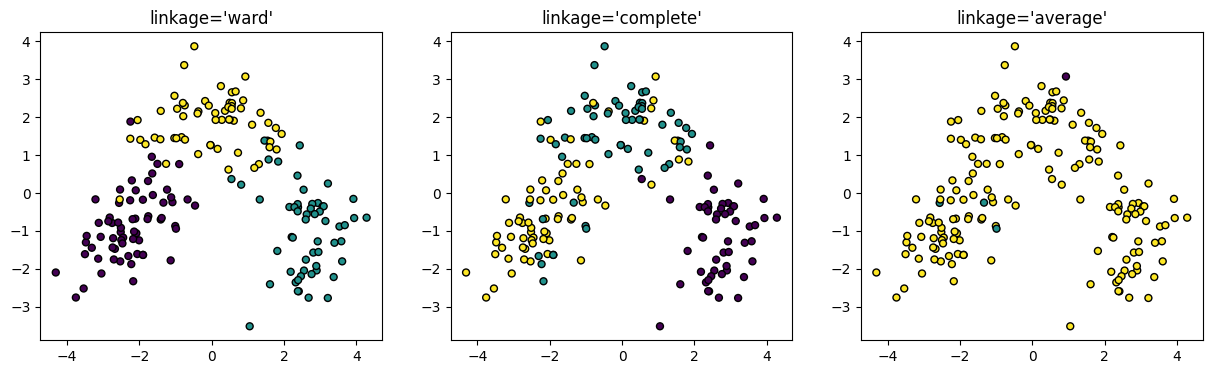

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, linkage in zip(axes, ("ward", "complete", "average")):
    agg = AgglomerativeClustering(n_clusters=3, linkage=linkage).fit(X)
    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=agg.labels_, cmap="viridis", edgecolors="k", s=25)
    ax.set_title(f"linkage='{linkage}'")
plt.show()


## 7. Gaussian Mixture Model — soft clustering via Expectation-Maximization

Unlike K-Means' hard assignments, a GMM gives every point a
*probability* of belonging to each cluster — useful when cluster
boundaries genuinely overlap.

In [9]:
gmm = GaussianMixtureModel(n_components=3, random_state=0).fit(X)
proba = gmm.predict_proba(X)
labels = gmm.predict(X)

print(f"converged: {gmm.converged_}  (in {gmm.n_iter_} EM iterations)")
uncertain = np.argsort(proba.max(axis=1))[:5]
print("\n5 most 'ambiguous' wines (lowest max cluster probability):")
for i in uncertain:
    print(f"  wine #{i}: cluster probabilities = {proba[i].round(2)}")


converged: True  (in 28 EM iterations)

5 most 'ambiguous' wines (lowest max cluster probability):
  wine #48: cluster probabilities = [0.68 0.32 0.  ]
  wine #4: cluster probabilities = [0.69 0.31 0.  ]
  wine #12: cluster probabilities = [0.85 0.15 0.  ]
  wine #36: cluster probabilities = [0.88 0.12 0.  ]
  wine #127: cluster probabilities = [0.92 0.08 0.  ]


## 8. FastICA — the "cocktail party problem"

Independent Component Analysis recovers the original *independent*
source signals from a linear mixture — the textbook example: two
people talking at once, recorded by two microphones at different
positions; ICA un-mixes the recordings back into two separate voices.
We reproduce the classic synthetic version with two distinct waveforms.

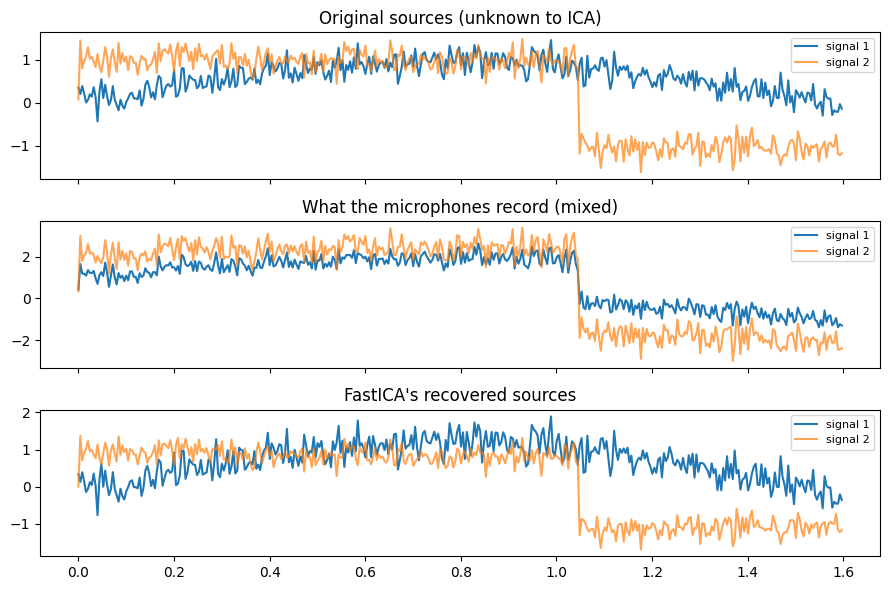

Up to sign/scale/ordering ambiguity (inherent to ICA), the two waveform
shapes are recovered — compare the sine and square-wave shapes above.


In [10]:
t = np.linspace(0, 8, 2000)
s1 = np.sin(2 * t)                                    # sine wave "voice 1"
s2 = np.sign(np.sin(3 * t))                           # square wave "voice 2"
S = np.c_[s1, s2]
S += 0.2 * np.random.randn(*S.shape)                  # mic noise
A = np.array([[1.0, 1.0], [0.5, 2.0]])                # unknown mixing (room acoustics)
X_mixed = S @ A.T                                      # what the two microphones actually hear

ica = FastICA(n_components=2, random_state=0).fit(X_mixed)
S_recovered = ica.transform(X_mixed)

fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
for ax, data, title in zip(
    axes, [S, X_mixed, S_recovered],
    ["Original sources (unknown to ICA)", "What the microphones record (mixed)", "FastICA's recovered sources"],
):
    ax.plot(t[:400], data[:400, 0], label="signal 1")
    ax.plot(t[:400], data[:400, 1], label="signal 2", alpha=0.7)
    ax.set_title(title); ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()
print("Up to sign/scale/ordering ambiguity (inherent to ICA), the two waveform")
print("shapes are recovered — compare the sine and square-wave shapes above.")


## 9. t-SNE — non-linear embedding for visualisation

t-SNE preserves *local* neighborhood structure, often separating
classes more crisply than PCA's linear projection — at the cost of
being a visualisation tool only (no `transform()` for new points).
We run it on a subset of the Digits dataset (real handwritten digit
images, 8x8 pixels) since t-SNE is the standard way to visualise
high-dimensional image embeddings.

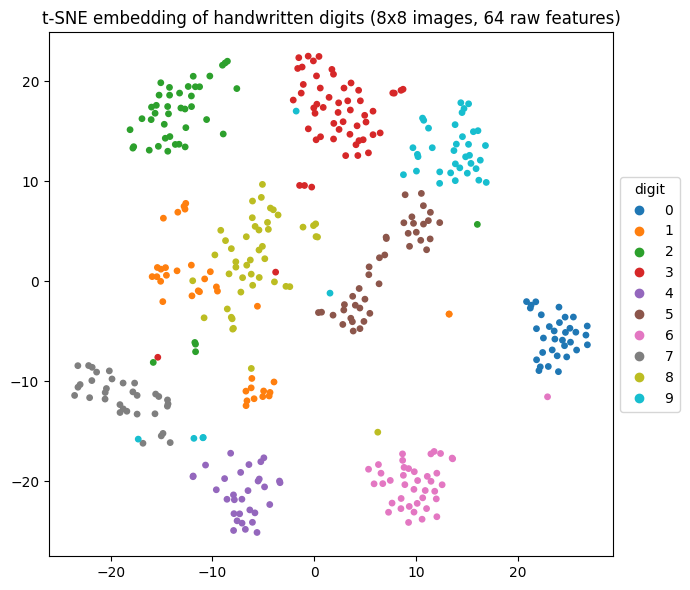

In [11]:
digits = load_digits()
n_sub = 400
idx = np.random.default_rng(0).choice(len(digits.data), n_sub, replace=False)
Xdig, ydig = digits.data[idx], digits.target[idx]

tsne = TSNE(n_components=2, perplexity=30, n_iter=500, random_state=0)
X_embedded = tsne.fit_transform(Xdig.astype(np.float64))

plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=ydig, cmap="tab10", s=15)
plt.legend(*scatter.legend_elements(), title="digit", loc="center left", bbox_to_anchor=(1, 0.5))
plt.title("t-SNE embedding of handwritten digits (8x8 images, 64 raw features)")
plt.tight_layout()
plt.show()


## 10. Apriori — market basket analysis

Finds frequent itemsets and "if A then B" association rules in
transactional data — the algorithm behind "customers who bought X also
bought Y". We use a small, realistic grocery-basket dataset.

In [12]:
transactions = [
    ["milk", "bread", "eggs"],
    ["milk", "bread"],
    ["milk", "eggs", "butter"],
    ["bread", "eggs", "butter"],
    ["milk", "bread", "eggs", "butter"],
    ["bread", "butter"],
    ["milk", "bread", "butter"],
    ["eggs", "butter"],
    ["milk", "bread", "eggs", "butter"],
    ["bread", "eggs"],
]

apriori = Apriori(min_support=0.3, min_confidence=0.6, min_lift=1.0).fit(transactions)

print("Frequent itemsets (support >= 0.3):")
for itemset, support in sorted(apriori.get_frequent_itemsets(), key=lambda t: -t[1])[:8]:
    print(f"  {set(itemset)}  support={support:.2f}")

print("\nAssociation rules (confidence >= 0.6):")
for rule in sorted(apriori.get_rules(), key=lambda r: -r['confidence'])[:5]:
    print(f"  {set(rule['antecedent'])} -> {set(rule['consequent'])}  "
          f"(confidence={rule['confidence']:.2f}, lift={rule['lift']:.2f})")


Frequent itemsets (support >= 0.3):
  {'bread'}  support=0.80
  {'butter'}  support=0.70
  {'eggs'}  support=0.70
  {'milk'}  support=0.60
  {'butter', 'bread'}  support=0.50
  {'eggs', 'bread'}  support=0.50
  {'milk', 'bread'}  support=0.50
  {'eggs', 'butter'}  support=0.50

Association rules (confidence >= 0.6):
  {'milk'} -> {'bread'}  (confidence=0.83, lift=1.04)
  {'eggs', 'milk'} -> {'butter'}  (confidence=0.75, lift=1.07)
  {'milk', 'butter'} -> {'eggs'}  (confidence=0.75, lift=1.07)
  {'eggs'} -> {'butter'}  (confidence=0.71, lift=1.02)
  {'butter'} -> {'eggs'}  (confidence=0.71, lift=1.02)


## Next steps

- See **`01_supervised_learning.ipynb`** for regression, classification, and ensembles
- See **`03_bayesian_methods.ipynb`** for Naive Bayes, Gaussian Processes, HMMs, and more
- See **`04_reinforcement_learning.ipynb`** for Q-Learning through SAC
- See **`05_neural_networks.ipynb`** for MLPs, RNNs, CNNs, Transformers, and GANs

⭐ If this was useful, star the repo:
https://github.com/Mattral/ML-AI-Algorithms-from-scratch
